## Below is the code to recreate Figure 7.

Topic: Showing the simulated Pleiades cluster (via best-fit isochrone) against actual Pleiades data from UKIDSS.

In [1]:
# Importing necessary packages.
from spisea import synthetic, evolution, atmospheres, reddening, ifmr
from spisea.imf import imf, multiplicity
import numpy as np
import pandas as pd
import pylab as py
import pdb
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table, vstack
%matplotlib inline
%load_ext autoreload
%autoreload

In [2]:
# simulate Pleiades-like cluster (mass=800 M_sun, distance=440 ly -- http://www.pleiade.org/pleiades_03.html)
    # age= 7.99, z = 0.015, per paper (Alfonso et al., 2023)

In [3]:
# Define isochrone parameters
logAge = 8.10 # Age in log(years)
AKs = 0.0 # extinction in mags (from https://academic.oup.com/mnras/article/343/4/1263/1067893)
dist = 134.905 # distance in parsec
metallicity = 0 # Metallicity in [M/H]

# Define evolution/atmosphere models and extinction law
evo_model = evolution.MergedPhillipsBaraffePisaEkstromParsec() 
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawHosek18b()

# Specify Gaia filters
ukidss_filts = ['ukirt,J', 'ukirt,H', 'ukirt,K']

# Specify the directory we want the output isochrone
# table saved in. If the directory does not already exist,
# SPISEA will create it.
iso_dir = 'isochrones/'

# Make IsochronePhot object. Note that this will take a minute or two, 
# unless the isochrone has been generated previously.
#
# Note that this is not show all of the user options 
# for IsochronePhot. See docs for complete list of options.
my_iso = synthetic.IsochronePhot(logAge, AKs, dist, metallicity=0,
                            evo_model=evo_model, atm_func=atm_func,
                            red_law=red_law, filters=ukidss_filts,
                                iso_dir=iso_dir, recomp=True)

Changing to T=   250 for T=   248 logg=3.06
Changing to logg=5.00 for T=  1542 logg=4.64
Changing to logg=5.00 for T=  1587 logg=4.66
Changing to logg=5.00 for T=  1632 logg=4.68
Changing to logg=5.00 for T=  1677 logg=4.70
Changing to logg=5.00 for T=  1725 logg=4.71
Changing to logg=5.00 for T=  1775 logg=4.73
Changing to logg=5.00 for T=  1820 logg=4.74
Changing to logg=5.00 for T=  1858 logg=4.75
Changing to logg=5.00 for T=  1895 logg=4.76
Changing to logg=5.00 for T=  1936 logg=4.78
Changing to logg=5.00 for T=  1977 logg=4.79
Isochrone generation took 13.891200 s.
Making photometry for isochrone: log(t) = 8.10  AKs = 0.00  dist = 134
     Starting at:  2026-04-03 17:08:33.466620   Usually takes ~5 minutes
Starting filter: ukirt,J   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.001 Msun  T =   248 K  m_ukirt_J = 34.45
M =   0.316 Msun  T =  3192 K  m_ukirt_J = 13.27
M =   4.612 Msun  T = 11585 K  m_ukirt_J = 3.50
M =   4.833 Msun  T =  3785 K  m_ukirt_J = -0.44

In [4]:
m = my_iso.points['mass']

phillips = (m < 0.07) & (m >= 0.01)
phillips_baraffe = (m >= 0.07) & (m < 0.075)

baraffe = (m >= 0.075) & (m < 0.4)
baraffe_pisa = (m >= 0.4) & (m < 0.5)

pisa = (m >= 0.5) & (m < 7.0)
ms = m >= 7.0   # Ekstrom at this age

color = my_iso.points['m_ukirt_J'] - my_iso.points['m_ukirt_K']
mag   = my_iso.points['m_ukirt_J']

In [5]:
# plotting simulated Pleiades cluster
imf_multi = multiplicity.MultiplicityUnresolved()
my_imf = imf.Salpeter_Kirkpatrick_2024(multiplicity=imf_multi)

mass = 800.
# Make cluster object
cluster = synthetic.ResolvedCluster(my_iso, my_imf, mass)

clust = cluster.star_systems
iso = my_iso.points

mask = (my_iso.points['mass'] >= 0.01)

# Look at the cluster CMD, compared to input isochrone. Note the impact of
# multiple systems on the photometry
clust = cluster.star_systems
iso = my_iso.points[mask]

Found 12 stars out of mass range


In [6]:
# read in ukidss data
other = '/System/Volumes/Data/mnt/g3/scratch/caitlinbegbie/code/SPISEA/docs/paper_examples/Begbie+26/cluster_data/asu (2).fit'
tab = Table.read(other, format='fits', hdu=2)

focus = np.where((tab['Jmag'] - tab['K2mag'] < 10))
minus = tab['Jmag'] - tab['K2mag']
J_K = minus[focus]

j_err = tab['e_Jmag']
k_err = tab['e_K1mag']
jk_err = np.sqrt(j_err**2 + k_err**2)

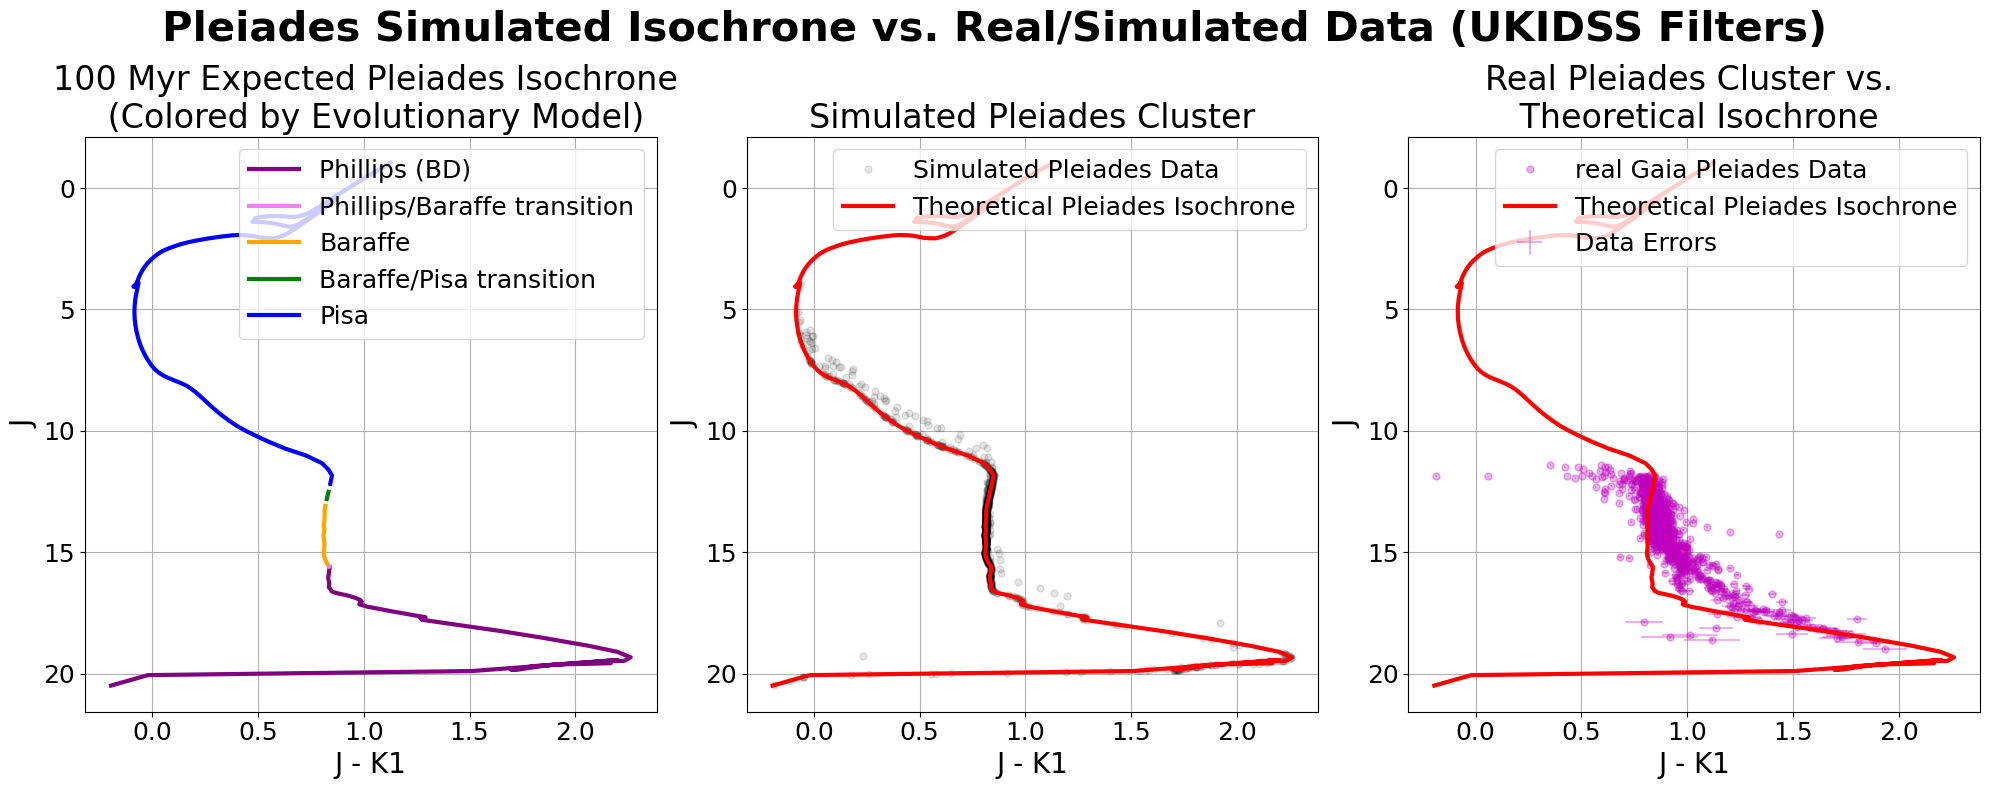

In [7]:
# Plotting all together
fig, axs = plt.subplots(1, 3, figsize=(20,8))

plt.suptitle('Pleiades Simulated Isochrone vs. Real/Simulated Data (UKIDSS Filters)', fontsize=30, fontweight='bold')

axs[0].plot(color[phillips], mag[phillips], '-', color='purple', label='Phillips (BD)', linewidth=3)
axs[0].plot(color[phillips_baraffe], mag[phillips_baraffe], '-', color='violet', label='Phillips/Baraffe transition', linewidth=3)
axs[0].plot(color[baraffe], mag[baraffe], '-', color='orange', label='Baraffe', linewidth=3)
axs[0].plot(color[baraffe_pisa], mag[baraffe_pisa], '-', color='green', label='Baraffe/Pisa transition', linewidth=3)
axs[0].plot(color[pisa], mag[pisa], '-', color='blue', label='Pisa', linewidth=3)
#axs[0].plot(color[ms], mag[ms], '-', color='red', label='Ekstrom MS', linewidth=3)
axs[0].invert_yaxis()
axs[0].set_xlabel('J - K1', fontsize=20)
axs[0].set_ylabel('J', fontsize=20)
axs[0].set_title('100 Myr Expected Pleiades Isochrone \n (Colored by Evolutionary Model)', fontsize=24)
axs[0].legend(markerscale=4, fontsize=18, loc='upper right')
axs[0].tick_params(axis='both', labelsize=18)
axs[0].grid()

axs[1].plot(clust['m_ukirt_J'] - clust['m_ukirt_K'], clust['m_ukirt_J'],
       'k.', ms=10, alpha=0.1, label='Simulated Pleiades Data')
axs[1].plot(my_iso.points['m_ukirt_J'][mask] - my_iso.points['m_ukirt_K'][mask], 
       my_iso.points['m_ukirt_J'][mask],
       'r-', linewidth=3, label='Theoretical Pleiades Isochrone')
axs[1].set_xlabel('J - K1', fontsize=20)
axs[1].set_ylabel('J', fontsize=20)
axs[1].invert_yaxis()
axs[1].set_title('Simulated Pleiades Cluster', fontsize=24)
axs[1].legend(fontsize=18, loc='upper right')
axs[1].tick_params(axis='both', labelsize=18)
axs[1].grid()

axs[2].plot(J_K, tab['Jmag'][focus],
       'm.', ms=10, alpha=0.3, label='real Gaia Pleiades Data')
axs[2].errorbar(J_K, tab['Jmag'][focus], xerr=jk_err[focus], yerr=j_err[focus], color='m', fmt='none', ms=5, alpha=0.3, label='Data Errors')
axs[2].plot(my_iso.points['m_ukirt_J'][mask] - my_iso.points['m_ukirt_K'][mask], 
       my_iso.points['m_ukirt_J'][mask],
       'r-', linewidth=3, label='Theoretical Pleiades Isochrone')
axs[2].set_xlabel('J - K1', fontsize=20)
axs[2].set_ylabel('J', fontsize=20)
axs[2].invert_yaxis()
axs[2].set_title('Real Pleiades Cluster vs. \n Theoretical Isochrone', fontsize=24)
axs[2].legend(fontsize=18, loc='upper right')
axs[2].tick_params(axis='both', labelsize=18)
axs[2].grid()

plt.tight_layout()
#plt.savefig('pleiades_ukidss.png')
plt.show()